#### 1. DOWNLOADING DATA

In [1]:
# importing necessary library
import torch 
from torch import nn

print(f"Version of torch: {torch.__version__}")

Version of torch: 2.10.0+cu128


In [2]:
!nvidia-smi

Thu Apr  2 11:34:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Setting device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# Downloading data 
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


#### 2. VISUALIZE IMAGE

In [5]:
image_path

PosixPath('data/pizza_steak_sushi')

In [6]:
import os
def walk_through_dir(dir_path):
    for dirpath, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")

In [7]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'


In [8]:
train_dir = image_path/ "train"
test_dir = image_path/ "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [9]:
image_path

PosixPath('data/pizza_steak_sushi')

In [10]:
image_path_list = list(image_path.glob('*/*/*.jpg'))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/sushi/858157.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/46797.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2190404.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3177743.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/207578.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3806282.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2385731.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3196729.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1742201.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1172255.jpg')]

Image path: data/pizza_steak_sushi/test/pizza/344397.jpg
Class name: pizza
Height: 342
Width: 512


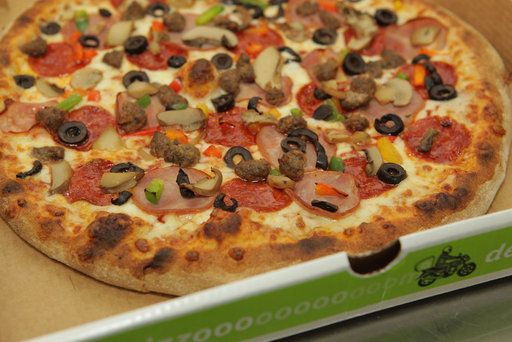

In [11]:
import random 
from PIL import Image 

random.seed(42)

image_path_list = list(image_path.glob('*/*/*.jpg'))

random_image_path = random.choice(image_path_list)
# print(random_image_path)

image_class = random_image_path.parent.stem
# print(image_class)

img = Image.open(random_image_path)
print(f"Image path: {random_image_path}")
print(f"Class name: {image_class}")
print(f"Height: {img.height}")
print(f"Width: {img.width}")
img

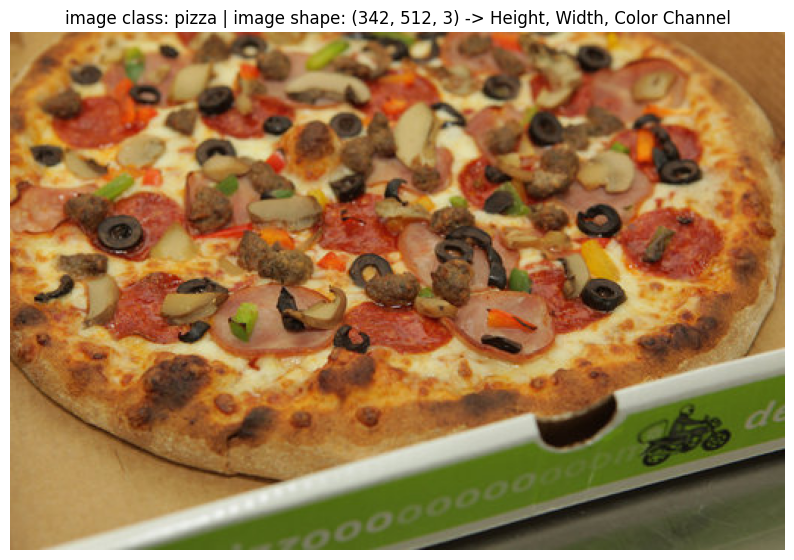

In [12]:
import numpy as np 
import matplotlib.pyplot as plt 

image_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(image_array)
plt.title(f"image class: {image_class} | image shape: {image_array.shape} -> Height, Width, Color Channel")
plt.axis("off")
plt.show()

#### 3. Transform Data

In [13]:
import torchvision

In [14]:
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [15]:
transforms_data = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.ToTensor() ])

In [16]:
transforms_data(img)

tensor([[[0.6000, 0.6235, 0.7020,  ..., 0.6314, 0.6392, 0.6510],
         [0.5961, 0.6118, 0.6902,  ..., 0.6275, 0.6353, 0.6392],
         [0.6157, 0.6196, 0.6784,  ..., 0.6196, 0.6196, 0.6353],
         ...,
         [0.6627, 0.6706, 0.6745,  ..., 0.4196, 0.4275, 0.4314],
         [0.6667, 0.6745, 0.6745,  ..., 0.4431, 0.4510, 0.4549],
         [0.6549, 0.6706, 0.6706,  ..., 0.4588, 0.4627, 0.4706]],

        [[0.3922, 0.4353, 0.5373,  ..., 0.4275, 0.4275, 0.4588],
         [0.3922, 0.4196, 0.5255,  ..., 0.4196, 0.4275, 0.4353],
         [0.4196, 0.4235, 0.5137,  ..., 0.4118, 0.4118, 0.4235],
         ...,
         [0.5176, 0.5294, 0.5373,  ..., 0.4118, 0.4196, 0.4275],
         [0.5216, 0.5294, 0.5333,  ..., 0.4314, 0.4392, 0.4431],
         [0.5098, 0.5255, 0.5333,  ..., 0.4471, 0.4510, 0.4588]],

        [[0.1725, 0.2078, 0.2980,  ..., 0.2039, 0.2157, 0.2314],
         [0.1725, 0.1961, 0.2902,  ..., 0.2039, 0.2157, 0.2196],
         [0.1961, 0.2000, 0.2824,  ..., 0.2078, 0.2039, 0.

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

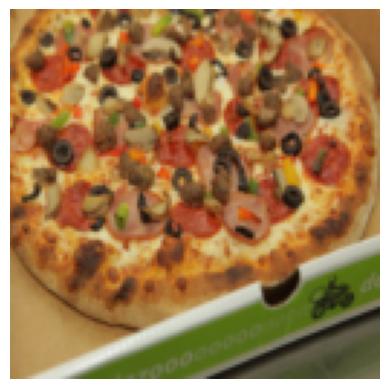

In [17]:
plt.imshow(transforms_data(img).permute(1,2,0))
plt.axis("off")

In [18]:
def plot_transformed_image(image_path_list, transforms, n=3, seed=42):
    random.seed(seed)
    random_image_path = random.sample(image_path_list, k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f: 
            fig, ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\n size:{f.size}")
            ax[0].axis("off")
            
            transformed_image = transforms(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\n size:{transformed_image.shape}")
            ax[1].axis("off")
            
            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


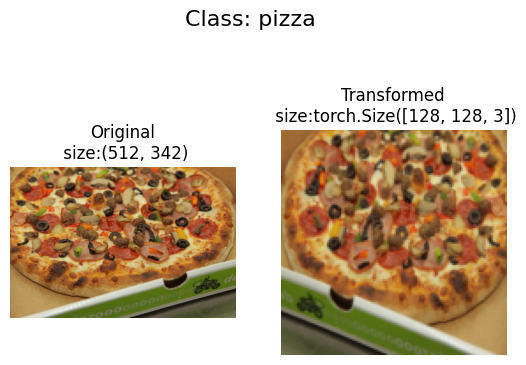

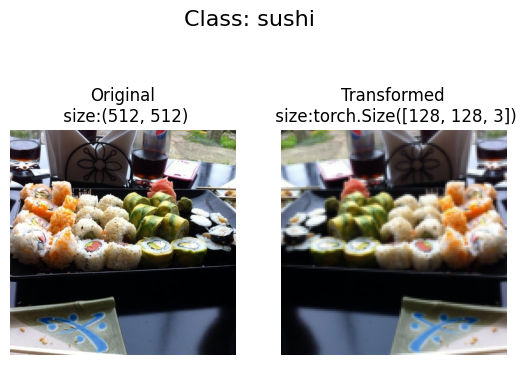

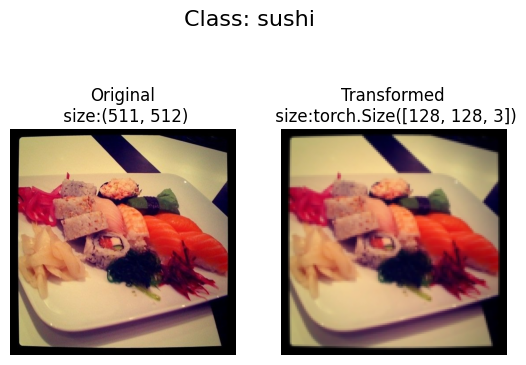

In [19]:
plot_transformed_image(image_path_list=image_path_list, 
                       transforms=transforms_data, )

#### 4. LOADING IMAGE

In [20]:
train_dir

PosixPath('data/pizza_steak_sushi/train')

In [21]:
# option 1: using ImageFolder
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir, 
                                  transform= transforms_data, 
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir, 
                                  transform= transforms_data, 
                                  target_transform=None)

In [22]:
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [23]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [24]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [25]:
len(train_data), len(test_data)

(225, 75)

In [26]:
train_data[0]

(tensor([[[0.1137, 0.1098, 0.1098,  ..., 0.1059, 0.1137, 0.1137],
          [0.1255, 0.1216, 0.1216,  ..., 0.1059, 0.1098, 0.1137],
          [0.1333, 0.1294, 0.1294,  ..., 0.1020, 0.1059, 0.1098],
          ...,
          [0.1765, 0.1686, 0.1647,  ..., 0.0902, 0.0863, 0.0824],
          [0.1765, 0.1686, 0.1647,  ..., 0.0824, 0.0863, 0.0902],
          [0.1608, 0.1569, 0.1569,  ..., 0.0824, 0.0824, 0.0863]],
 
         [[0.0588, 0.0549, 0.0549,  ..., 0.0706, 0.0745, 0.0706],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0667, 0.0627, 0.0627,  ..., 0.0745, 0.0745, 0.0745],
          ...,
          [0.2314, 0.2275, 0.2275,  ..., 0.1098, 0.1098, 0.1059],
          [0.2314, 0.2314, 0.2275,  ..., 0.1020, 0.1020, 0.1059],
          [0.2275, 0.2275, 0.2353,  ..., 0.0980, 0.0980, 0.1020]],
 
         [[0.0196, 0.0196, 0.0196,  ..., 0.0902, 0.0980, 0.0941],
          [0.0235, 0.0235, 0.0235,  ..., 0.0902, 0.0941, 0.0941],
          [0.0196, 0.0157, 0.0196,  ...,

In [27]:
image, label = train_data[0][0], train_data[0][1]

In [28]:
print(f"Image tensor:\n{image}")
print(f"Image shape: {image.shape}")
print(f"Image datatype: {image.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[0.1137, 0.1137, 0.1059,  ..., 0.1098, 0.1098, 0.1137],
         [0.1137, 0.1098, 0.1059,  ..., 0.1216, 0.1216, 0.1255],
         [0.1098, 0.1059, 0.1020,  ..., 0.1294, 0.1294, 0.1333],
         ...,
         [0.0824, 0.0863, 0.0902,  ..., 0.1647, 0.1686, 0.1765],
         [0.0902, 0.0863, 0.0824,  ..., 0.1647, 0.1686, 0.1765],
         [0.0863, 0.0824, 0.0824,  ..., 0.1569, 0.1569, 0.1608]],

        [[0.0706, 0.0745, 0.0706,  ..., 0.0549, 0.0549, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0745, 0.0745, 0.0745,  ..., 0.0627, 0.0627, 0.0667],
         ...,
         [0.1059, 0.1098, 0.1098,  ..., 0.2275, 0.2275, 0.2314],
         [0.1059, 0.1020, 0.1020,  ..., 0.2275, 0.2314, 0.2314],
         [0.1020, 0.0980, 0.0980,  ..., 0.2353, 0.2275, 0.2275]],

        [[0.0941, 0.0980, 0.0902,  ..., 0.0196, 0.0196, 0.0196],
         [0.0941, 0.0941, 0.0902,  ..., 0.0235, 0.0235, 0.0235],
         [0.0941, 0.0941, 0.0902,  ..., 0.01

Original shape: torch.Size([3, 128, 128]) -> [color_channels, height, width]
Image permute shape: torch.Size([128, 128, 3]) -> [height, width, color_channels]


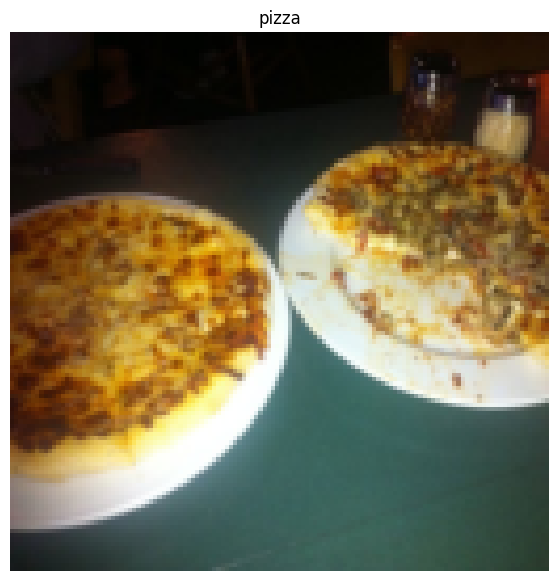

In [29]:
image_permuted = image.permute(1,2,0)

# Print out different shapes (before and after permute)
print(f"Original shape: {image.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {image_permuted.shape} -> [height, width, color_channels]")


plt.figure(figsize=(10,7))
plt.imshow(image_permuted)
plt.title(label=class_names[label])
plt.axis("off")
plt.show()

In [30]:
import os 
os.cpu_count()

2

In [31]:
# Loading Image tensor using DataLoader 
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data, 
                              batch_size=16, 
                              shuffle=True, 
                              num_workers=2)

test_dataloader = DataLoader(dataset=test_data, 
                             batch_size=16, 
                             shuffle=False, 
                             num_workers=2)


In [32]:
img, label = next(iter(train_dataloader))

In [33]:
print(f"Shape of image: {img.shape} -> [batch_size, Color_Channel, Height, Width]")
print(f"Label: {label}")

Shape of image: torch.Size([16, 3, 128, 128]) -> [batch_size, Color_Channel, Height, Width]
Label: tensor([2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 2, 1, 2, 2, 2, 0])


Text(0.5, 1.0, 'sushi')

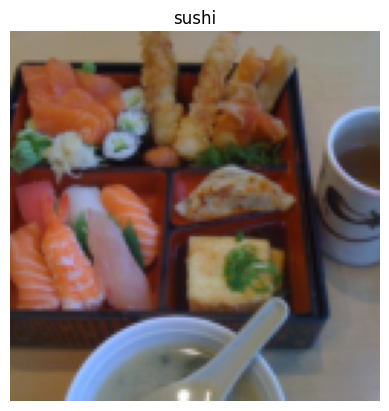

In [34]:
image = img[0]
plt.imshow(image.permute(1,2,0))
plt.axis("off")
plt.title(class_names[label[0]])

In [35]:
# #### Option 2: Loading Image Data with a Custom Dataset
# import torch 
# import os 
# import pathlib 

# from PIL import Image 
# from torch.utils.data import Dataset
# from typing import Dict, Tuple, List

In [36]:
# train_data.classes, train_data.class_to_idx

In [37]:
# train_dir

In [38]:
# train_directory = train_dir

In [39]:
# classes = [entry.name for entry in list( os.scandir(train_directory))]
# classes

In [40]:
# def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
#     classes = sorted([entry.name for entry in list(os.scandir(directory)) if entry.is_dir()])
#     if not classes:
#         raise FileNotFoundError(f"Couldn't find any classes in {directory}.")
    
#     class_to_idx = {class_name:index  for index,class_name in enumerate(classes)}
    
#     return classes, class_to_idx
    

In [41]:
# find_classes(train_directory)

In [42]:
# # Write a custom dataset class (inherits from torch.utils.data.Dataset)
# from torch.utils.data import Dataset

# # 1. Subclass torch.utils.data.Dataset
# class ImageFolderCustom(Dataset):
    
#     # 2. Initialize with a targ_dir and transform (optional) parameter
#     def __init__(self, targ_dir: str, transform=None) -> None:
        
#         # 3. Create class attributes
#         # Get all image paths
#         self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg")) # note: you'd have to update this if you've got .png's or .jpeg's
#         # Setup transforms
#         self.transform = transform
#         # Create classes and class_to_idx attributes
#         self.classes, self.class_to_idx = find_classes(targ_dir)

#     # 4. Make function to load images
#     def load_image(self, index: int) -> Image.Image:
#         "Opens an image via a path and returns it."
#         image_path = self.paths[index]
#         return Image.open(image_path) 
    
#     # 5. Overwrite the __len__() method (optional but recommended for subclasses of torch.utils.data.Dataset)
#     def __len__(self) -> int:
#         "Returns the total number of samples."
#         return len(self.paths)
    
#     # 6. Overwrite the __getitem__() method (required for subclasses of torch.utils.data.Dataset)
#     def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
#         "Returns one sample of data, data and label (X, y)."
#         img = self.load_image(index)
#         class_name  = self.paths[index].parent.name # expects path in data_folder/class_name/image.jpeg
#         class_idx = self.class_to_idx[class_name]

#         # Transform if necessary
#         if self.transform:
#             return self.transform(img), class_idx # return data, label (X, y)
#         else:
#             return img, class_idx # return data, label (X, y)

In [43]:
# # Augment train data
# train_transforms = transforms.Compose([
#     transforms.Resize((128, 128)),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.ToTensor()
# ])

# # Don't augment test data, only reshape
# test_transforms = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.ToTensor()
# ])

In [44]:
# train_data_custom = ImageFolderCustom(targ_dir=train_dir, 
#                                       transform=train_transforms)
# test_data_custom = ImageFolderCustom(targ_dir=test_dir, 
#                                      transform=test_transforms)
# train_data_custom, test_data_custom

In [45]:
# len(train_data_custom), len(test_data_custom)

In [46]:
# train_data_custom.classes

In [47]:
# train_data_custom.class_to_idx

In [48]:
# # Check for equality amongst our custom Dataset and ImageFolder Dataset
# print((len(train_data_custom) == len(train_data)) & (len(test_data_custom) == len(test_data)))
# print(train_data_custom.classes == train_data.classes)
# print(train_data_custom.class_to_idx == train_data.class_to_idx)

In [49]:
# class_names

In [50]:
# plot random images 
from typing import List
def display_random_images(dataset:torch.utils.data.Dataset, 
                          classes: List[str], 
                          n: int = 10,
                          display_shape:bool = True,
                          seed:int= True):
    if n > 10: 
        n = 10
        display_shape = False
        print("n should be not larger than 10.")
        
    if seed: 
        random.seed(seed)
        
    random_sample_idx = random.sample(range(len(dataset)), k=n)
    
    plt.figure(figsize=(10,7))
    
    for i, target_sample in enumerate(random_sample_idx):
        target_image, label = dataset[target_sample][0], dataset[target_sample][1]
        
        target_image_adjust = target_image.permute(1,2,0)
        
        plt.subplot(1, n, i+1)
        plt.imshow(target_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[label]}"
            if display_shape:
                title = title + f"\nshape: {target_image_adjust.shape}"
        plt.title(title)  
        

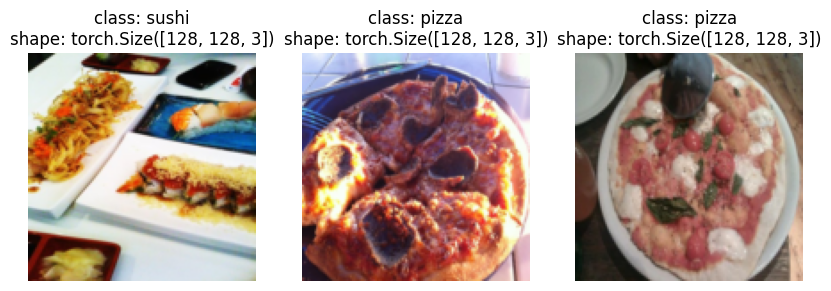

In [51]:
display_random_images(dataset=train_data, 
                      classes=class_names, 
                      n=3,
                      seed=42)

In [52]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), 
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

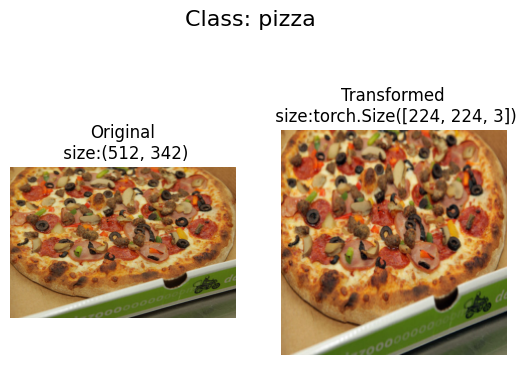

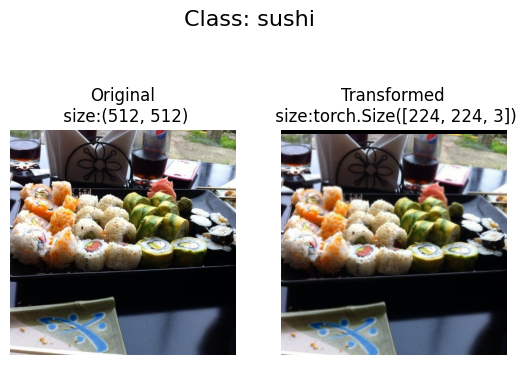

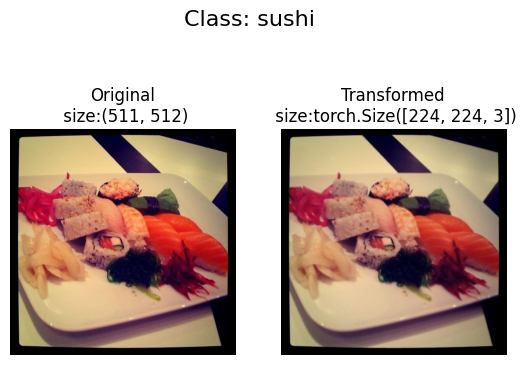

In [53]:
# visualize 
image_path_list = list(image_path.glob('*/*/*.jpg'))
# image_path_list[:3]

plot_transformed_image(image_path_list=image_path_list, 
                       transforms=train_transform, 
                       n=3, 
                       seed=42)


#### 5 Model0: TinyVGG without Augmentation 

In [54]:
# creating a simple image transformers without augmentataion
from torchvision import transforms
simple_transformer = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

In [55]:
print(f"Train Directory path: {train_dir}\nTest Directory path: {test_dir}")

Train Directory path: data/pizza_steak_sushi/train
Test Directory path: data/pizza_steak_sushi/test


In [56]:
# Transforming image using ImageFolder and creating dataloader 
from torchvision import datasets
import os 
from torch.utils.data import DataLoader

train_transformed_data = datasets.ImageFolder(root=train_dir, 
                                              transform=simple_transformer, 
                                              )
test_transformed_data = datasets.ImageFolder(root=test_dir, 
                                             transform=simple_transformer)

train_dataloader_simple = DataLoader(dataset=train_transformed_data, 
                                     batch_size=32, 
                                     shuffle=True, 
                                     num_workers=os.cpu_count())
test_dataloader_simple = DataLoader(dataset=test_transformed_data, 
                                    batch_size=32, 
                                    shuffle=False, 
                                    num_workers=os.cpu_count())
train_dataloader_simple, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x7aa3cbfc88c0>,
 <torch.utils.data.dataloader.DataLoader at 0x7aa3f0b548c0>)

In [57]:
# len(class_names)

In [58]:
# creating TinyVgg class using (nn.Module)
from torch import nn
class TinyVGGModel0(nn.Module):
    def __init__(self, 
                 input_shape: int, 
                 hidden_units: int, 
                 output_shape: int): 
        super().__init__()
        
        # convolutional block 1 
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=(3,3), 
                      stride=1), 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=(3,3), 
                      stride=1), 
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=(2,2), 
                         stride=(2,2))
            
        )
        
        # convolutional block 2 
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=(3,3), 
                      stride=1), 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units, 
                      kernel_size=(3,3), 
                      stride=1), 
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size=(2,2), 
                         stride=(2,2))
            
        )
        
        # classifier / linear layer 
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=hidden_units*13*13, 
                      out_features=output_shape)
        )
        
    # forward method 
    def forward(self, x:torch.Tensor): 
        x = self.conv_block_1(x)
        # print(x.shape)
        
        x = self.conv_block_2(x)
        # print(x.shape)
        
        x = self.classifier(x)
        # print(x.shape)
        
        # return(self.classifier(self.conv_block_2(self.conv_block_1(x)))) operator fusion 
        
        return x 
    
# create instance of TinyVGGModel0
model_0 = TinyVGGModel0(input_shape=3, # number of color channels
                        hidden_units=10, 
                        output_shape=len(class_names)).to(device)

In [59]:
model_0

TinyVGGModel0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [60]:
# lets test with one image_sample 
image_sample, label_sample = next(iter(train_dataloader_simple))
image_test , label_test = image_sample[0].unsqueeze(dim=0), label_sample[0]
image_test, label_test

(tensor([[[[0.6118, 0.6275, 0.6706,  ..., 0.0392, 0.0353, 0.0235],
           [0.6157, 0.6275, 0.6627,  ..., 0.1333, 0.1216, 0.1098],
           [0.5804, 0.6314, 0.6667,  ..., 0.1608, 0.1490, 0.1373],
           ...,
           [0.3765, 0.3961, 0.4157,  ..., 0.6863, 0.6588, 0.6353],
           [0.4588, 0.4863, 0.5059,  ..., 0.6588, 0.6353, 0.6078],
           [0.5843, 0.6039, 0.6235,  ..., 0.6353, 0.6118, 0.5843]],
 
          [[0.5569, 0.5686, 0.6118,  ..., 0.0392, 0.0275, 0.0157],
           [0.5725, 0.5725, 0.6039,  ..., 0.1216, 0.1098, 0.1020],
           [0.5373, 0.5843, 0.6118,  ..., 0.1451, 0.1333, 0.1294],
           ...,
           [0.3843, 0.4039, 0.4196,  ..., 0.7098, 0.6902, 0.6706],
           [0.4824, 0.5020, 0.5333,  ..., 0.6863, 0.6667, 0.6431],
           [0.6078, 0.6314, 0.6549,  ..., 0.6667, 0.6431, 0.6157]],
 
          [[0.3608, 0.3490, 0.3922,  ..., 0.0431, 0.0314, 0.0314],
           [0.3765, 0.3569, 0.3804,  ..., 0.1294, 0.1176, 0.1020],
           [0.3529, 0.38

In [61]:
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(image_test.to(device))

In [62]:
# 10*13*13

In [63]:
y_pred

tensor([[ 0.0412, -0.0500, -0.0155]], device='cuda:0')

In [64]:
try: 
    import torchinfo
except: 
    !pip install torchinfo
    import torchinfo
    

In [65]:
from torchinfo import summary

summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGModel0                            [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

In [ ]:
# Train and test Step 
def train_step(model:torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               optimizer: torch.nn.Module, 
               loss_fn: torch.optim.Optimizer, 
               device: torch.device):
    model.train()
    
    train_loss, train_accuracyuracy = 0, 0
    
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        # do the forward pass 
        y_pred_logits = model(X)
        
        # calculate the loss
        loss = loss_fn(y_pred_logits, y)
        train_loss += loss.item()
        
        y_pred = torch.argmax(torch.softmax(y_pred_logits, dim=1), dim=1)
        train_accuracyuracy += (y_pred == y).sum().item() / len(y_pred)
        
        # optimizer zero_grad()
        optimizer.zero_grad()
        
        # loss backward 
        loss.backward()
        
        # optimizer step 
        optimizer.step()
        
    train_loss += train_loss/ len(dataloader)
    train_accuracyuracy += train_accuracyuracy/len(dataloader)
    
    return train_loss, train_accuracyuracy
    

In [ ]:
# Train and test Step 
def test_step(model:torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.optim.Optimizer, 
               device: torch.device):
    
    model.eval()
    test_loss, test_accuracyuracy = 0, 0
    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            
            # do the forward pass 
            test_pred_logits = model(X)
            
            # calculate the loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item() 
            
            test_pred = torch.argmax(torch.softmax(test_pred_logits, dim=1), dim=1)
            test_accuracyuracyuracyuracy += (test_pred == y).sum().item() / len(test_pred)
            
            
        test_loss += test_loss/ len(dataloader)
        test_accuracyuracy += test_accuracyuracy/len(dataloader)
        
        return test_loss, test_accuracyuracy
    

In [ ]:
# Train Function 
from tqdm.auto import tqdm 
def train_function(model:torch.nn.Module, 
                   train_dataloader: torch.utils.data.DataLoader, 
                   test_dataloader: torch.utils.data.DataLoader, 
                   loss_fn: torch.nn.Module, 
                   optimizer: torch.optim.Optimizer, 
                   epochs: int): 
    
    results = {'train_loss': [], 
               'train_accuracyuracy': [], 
               'test_loss': [], 
               'test_accuracyuracy': []}
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_accuracy, =train_step(model=model, 
                        dataloader=train_dataloader, 
                        optimizer=optimizer, 
                        loss_fn=loss_fn, 
                        device=device)
        
        test_loss, test_accuracy = test_step(model=model, 
                  dataloader=test_dataloader, 
                  loss_fn=loss_fn, 
                  device=device)
        
        print(f"Train Loss: {train_loss:.2f} | Train Accuracy: {train_accuracy:.2f}%| Test Loss: {test_loss:.2f} | Test Accuracy: {test_accuracy:.2f}%")
        
        results['train_loss'].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results['train_accuracyuracy'].append(train_accuracy.item() if isinstance(train_accuracy, torch.Tensor) else train_accuracy)
        results['test_loss'].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results['test_accuracyuracy'].append(test_accuracy.item() if isinstance(test_accuracy, torch.Tensor) else test_accuracy)
    
    return results

In [69]:
# Training 
torch.manual_seed(42) 
torch.cuda.manual_seed(42)
epochs = 10

model_0 = TinyVGGModel0(input_shape=3, 
                        hidden_units=10, 
                        output_shape=3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), 
                                  lr=0.01)

from timeit import default_timer as timer 
start_time = timer()

results = train_function(model=model_0, 
                         train_dataloader=train_dataloader_simple, 
                         test_dataloader=test_dataloader_simple, 
                         loss_fn=loss_fn, 
                         optimizer=optimizer, 
                         epochs=epochs)

end_time = timer()
print(f'Total training time: {start_time-end_time}sec')

  0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 10.85 | Train Accuracy: 3.09%| Test Loss: 4.47 | Test Accuracy: 2.17%
Train Loss: 10.52 | Train Accuracy: 2.53%| Test Loss: 4.31 | Test Accuracy: 2.17%
Train Loss: 9.96 | Train Accuracy: 2.85%| Test Loss: 4.38 | Test Accuracy: 1.69%
Train Loss: 9.90 | Train Accuracy: 2.78%| Test Loss: 4.37 | Test Accuracy: 2.17%
Train Loss: 9.88 | Train Accuracy: 3.62%| Test Loss: 4.38 | Test Accuracy: 2.17%
Train Loss: 9.87 | Train Accuracy: 3.62%| Test Loss: 4.37 | Test Accuracy: 2.17%
Train Loss: 9.86 | Train Accuracy: 3.62%| Test Loss: 4.35 | Test Accuracy: 2.17%
Train Loss: 9.93 | Train Accuracy: 2.53%| Test Loss: 4.33 | Test Accuracy: 2.17%
Train Loss: 9.96 | Train Accuracy: 2.53%| Test Loss: 4.34 | Test Accuracy: 2.17%
Train Loss: 9.87 | Train Accuracy: 3.62%| Test Loss: 4.36 | Test Accuracy: 2.17%
Total training time: -10.243933119999838sec


In [70]:
model_0_results = results

In [71]:
model_0_results.keys()

dict_keys(['train_loss', 'train_accuracy', 'test_loss', 'test_accuracy'])

In [ ]:
from typing import Dict
# plot loss curves 
def plot_loss_curves(results: Dict[str, List[float]]):
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    
    train_accuracyuracy = results["train_accuracyuracy"]
    test_accuracyuracy = results["test_accuracyuracy"]
    
    epochs = range(len(results["train_loss"]))
    
    plt.figure(figsize=(15, 7))
     
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="train loss")
    plt.plot(epochs, test_loss, label="test loss")
    plt.xlabel("Epochs")
    plt.ylabel("loss")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(epochs, train_accuracyuracy, label="train accuracy")
    plt.plot(epochs, test_accuracyuracy, label="test accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    
    

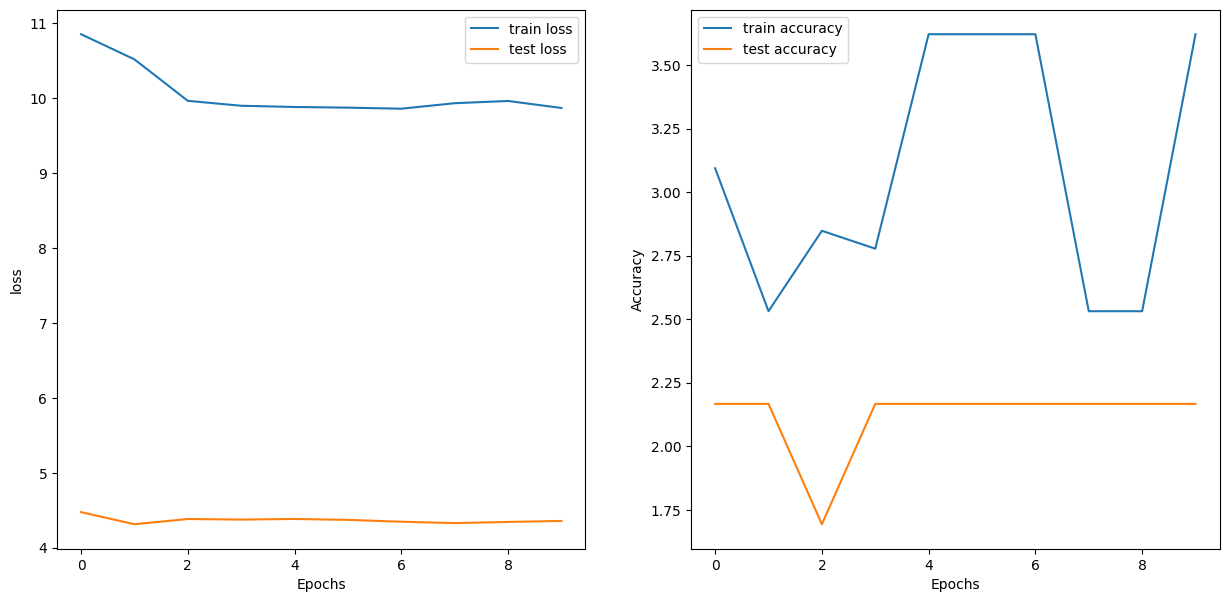

In [73]:
plot_loss_curves(model_0_results)

#### 6: MODEL1 WITH DATA AUGMENTATION

In [75]:
from torchvision import transforms, datasets

train_transform_augment = transforms.Compose([
    transforms.Resize((64,64)), 
    transforms.TrivialAugmentWide(num_magnitude_bins= 31), 
    transforms.ToTensor()
])

test_transform_augment = transforms.Compose([
    transforms.Resize((64,64)), 
    transforms.ToTensor()
])

In [77]:
train_transformed_datas = datasets.ImageFolder(root=train_dir, 
                                               transform = train_transform_augment)
test_transformed_datas = datasets.ImageFolder(root=test_dir, 
                                               transform = test_transform_augment)

In [78]:
train_transformed_datas, test_transformed_datas

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [83]:
# Turn Datasets into DataLoader's
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)
train_dataloader_augmented = DataLoader(train_transformed_datas, 
                                        batch_size=BATCH_SIZE, 
                                        shuffle=True,
                                        num_workers=NUM_WORKERS)

test_dataloader_augmented = DataLoader(test_transformed_datas, 
                                    batch_size=BATCH_SIZE, 
                                    shuffle=False, 
                                    num_workers=NUM_WORKERS)

train_dataloader_augmented, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7aa3cbef3560>,
 <torch.utils.data.dataloader.DataLoader at 0x7aa3d1cef740>)

In [84]:
# Create model_1 and send it to the target device
torch.manual_seed(42)
model_1 = TinyVGGModel0(
    input_shape=3,
    hidden_units=64,
    output_shape=3).to(device)
model_1

TinyVGGModel0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=10816, out_features=3, bias=True)
  )
)

In [89]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 10

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_1
model_1_results = train_function(model=model_1, 
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_augmented,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 5.34 | Train Accuracy: 6.96%| Test Loss: 4.80 | Test Accuracy: 1.82%
Train Loss: 8.57 | Train Accuracy: 5.91%| Test Loss: 4.25 | Test Accuracy: 2.02%
Train Loss: 4.92 | Train Accuracy: 7.14%| Test Loss: 4.09 | Test Accuracy: 1.82%
Train Loss: 5.24 | Train Accuracy: 6.79%| Test Loss: 4.36 | Test Accuracy: 2.06%
Train Loss: 4.25 | Train Accuracy: 7.49%| Test Loss: 4.02 | Test Accuracy: 2.02%
Train Loss: 7.06 | Train Accuracy: 6.26%| Test Loss: 4.20 | Test Accuracy: 2.02%
Train Loss: 5.53 | Train Accuracy: 6.79%| Test Loss: 3.91 | Test Accuracy: 2.03%
Train Loss: 4.85 | Train Accuracy: 7.31%| Test Loss: 3.80 | Test Accuracy: 2.27%
Train Loss: 5.07 | Train Accuracy: 7.52%| Test Loss: 3.57 | Test Accuracy: 2.52%
Train Loss: 4.69 | Train Accuracy: 7.03%| Test Loss: 3.56 | Test Accuracy: 2.75%
Total training time: 10.392 seconds


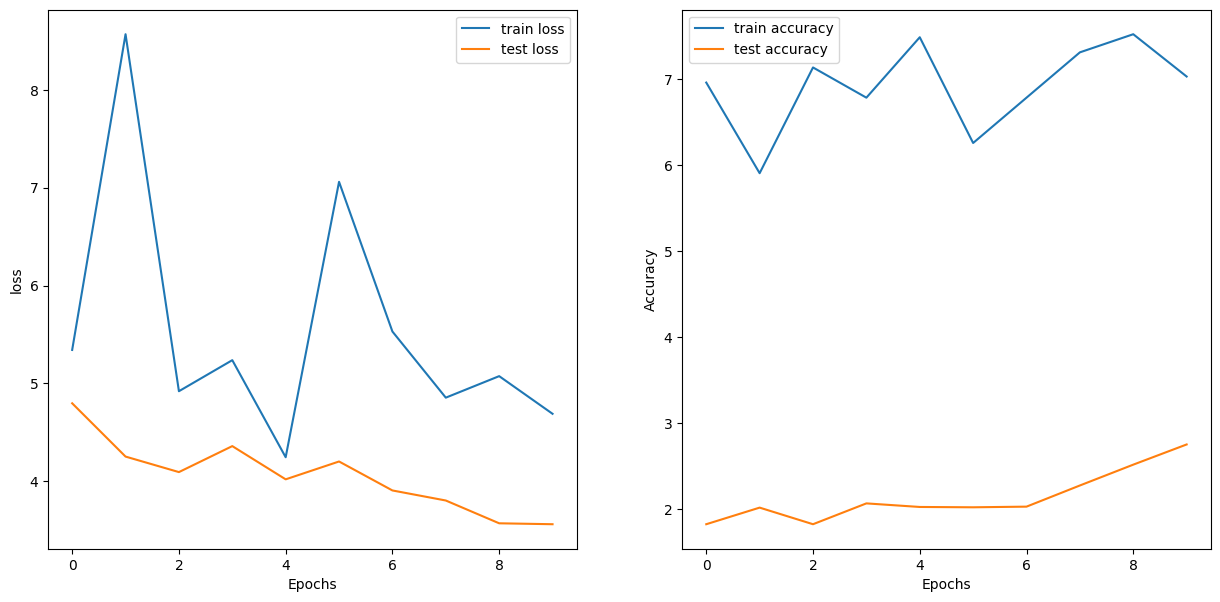

In [91]:
plot_loss_curves(results=model_1_results)

In [92]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)
model_0_df

,train_loss,train_accuracy,test_loss,test_accuracy
0,10.851905,3.093750,4.474269,2.166667
1,10.516488,2.531250,4.312903,2.166667
2,9.962856,2.847656,4.382359,1.693182
3,9.897267,2.777344,4.374834,2.166667
4,9.880996,3.621094,4.383153,2.166667
5,9.872043,3.621094,4.370756,2.166667
6,9.857926,3.621094,4.346228,2.166667
7,9.931440,2.531250,4.327954,2.166667
8,9.961130,2.531250,4.343351,2.166667
9,9.867582,3.621094,4.356772,2.166667


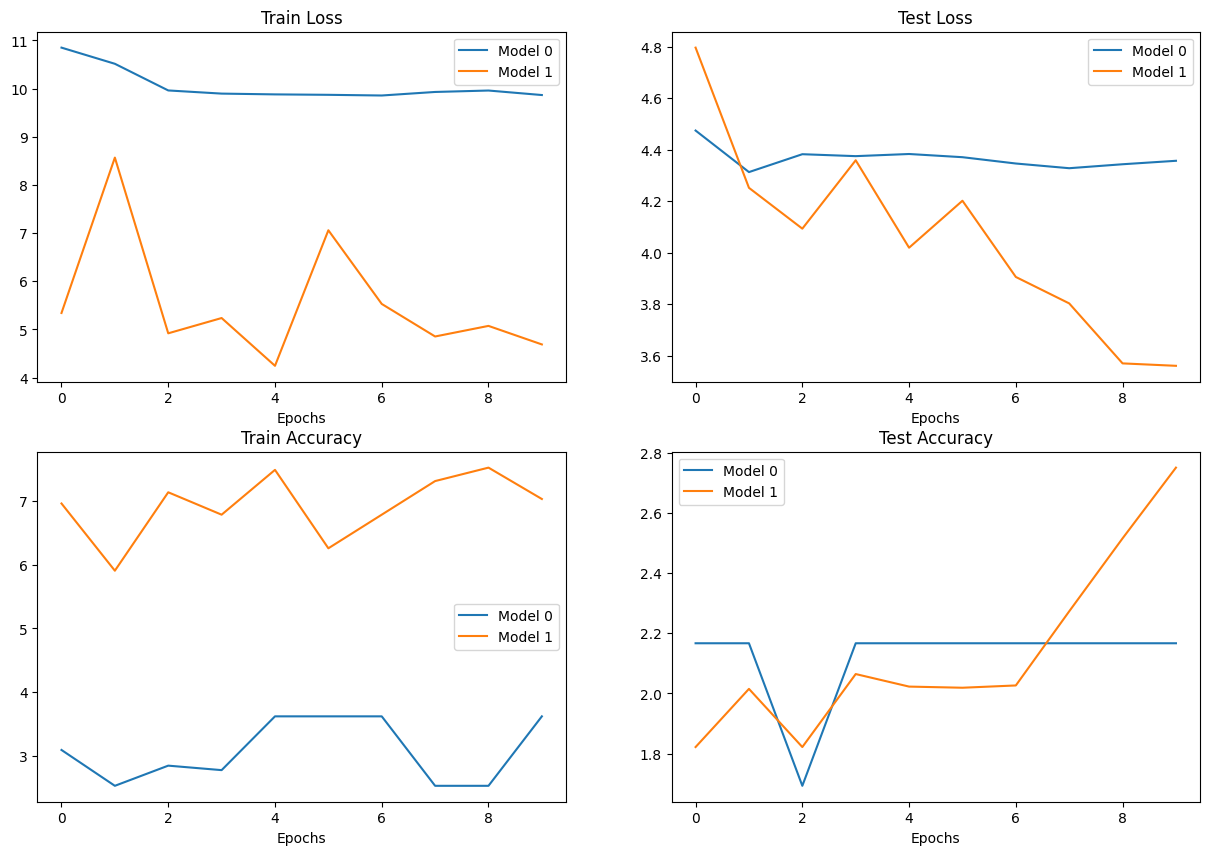

In [94]:
# Setup a plot 
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_0_df))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label="Model 0")
plt.plot(epochs, model_1_df["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label="Model 0")
plt.plot(epochs, model_1_df["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_accuracy"], label="Model 0")
plt.plot(epochs, model_1_df["train_accuracy"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_accuracy"], label="Model 0")
plt.plot(epochs, model_1_df["test_accuracy"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();